Model                | w          | w0         | MAE       
------------------------------------------------------------
Model A (Poor Fit)   | 0.05       | 5000       | 9690.88
Model B (Okay Fit)   | -0.05      | 35000      | 12681.43
Model C (Good Fit)   | -0.08      | 25000      | 1454.42


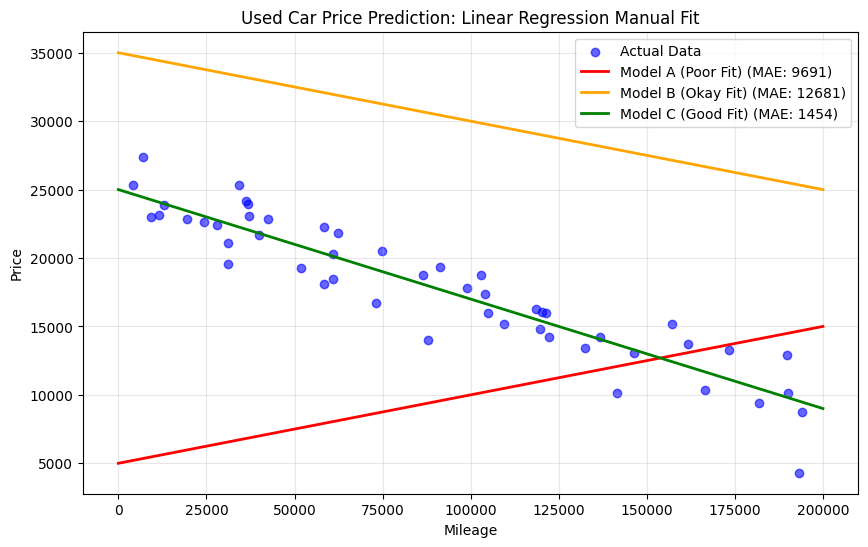

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_samples = 50


mileage = np.random.uniform(0, 200000, n_samples)

true_w = -0.08
true_w0 = 25000
noise = np.random.normal(0, 2000, n_samples)

price = (true_w * mileage) + true_w0 + noise


def estimate_price(x, w, w0):
    """
    Returns estimated price y = wx + w0
    x: mileage
    w: weight (slope)
    w0: bias (y-intercept)
    """
    return w * x + w0


def calculate_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


plt.figure(figsize=(10, 6))


plt.scatter(mileage, price, color='blue', label='Actual Data', alpha=0.6)


manual_models = [
    {"label": "Model A (Poor Fit)", "w": 0.05, "w0": 5000, "color": "red"},
    {"label": "Model B (Okay Fit)", "w": -0.05, "w0": 35000, "color": "orange"},
    {"label": "Model C (Good Fit)", "w": -0.08, "w0": 25000, "color": "green"}
]

print(f"{'Model':<20} | {'w':<10} | {'w0':<10} | {'MAE':<10}")
print("-" * 60)

for model in manual_models:
    w = model["w"]
    w0 = model["w0"]


    predictions = estimate_price(mileage, w, w0)


    mae = calculate_mae(price, predictions)


    x_range = np.linspace(0, 200000, 100)
    y_range = estimate_price(x_range, w, w0)
    plt.plot(x_range, y_range, color=model["color"], linewidth=2, label=f'{model["label"]} (MAE: {mae:.0f})')


    print(f"{model['label']:<20} | {w:<10} | {w0:<10} | {mae:.2f}")

plt.title("Used Car Price Prediction: Linear Regression Manual Fit")
plt.xlabel("Mileage") #
plt.ylabel("Price")   #
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Selected Thresholds -> Income: 50, Savings: 20
Classifier Accuracy: 99.00%


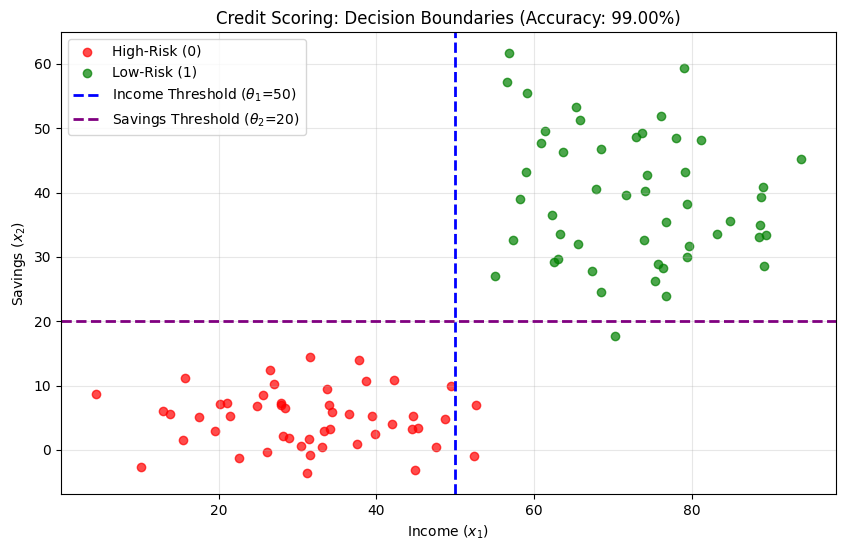

In [2]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(0)
n_samples = 50


high_risk_income = np.random.normal(30, 10, n_samples)
high_risk_savings = np.random.normal(5, 5, n_samples)
high_risk_labels = np.zeros(n_samples)


low_risk_income = np.random.normal(70, 10, n_samples)
low_risk_savings = np.random.normal(40, 10, n_samples)
low_risk_labels = np.ones(n_samples)


income = np.concatenate([high_risk_income, low_risk_income])
savings = np.concatenate([high_risk_savings, low_risk_savings])
labels = np.concatenate([high_risk_labels, low_risk_labels])


plt.figure(figsize=(10, 6))
plt.scatter(high_risk_income, high_risk_savings, color='red', label='High-Risk (0)', alpha=0.7)
plt.scatter(low_risk_income, low_risk_savings, color='green', label='Low-Risk (1)', alpha=0.7)


theta1 = 50
theta2 = 20


plt.axvline(x=theta1, color='blue', linestyle='--', linewidth=2, label=f'Income Threshold ($\\theta_1$={theta1})')

plt.axhline(y=theta2, color='purple', linestyle='--', linewidth=2, label=f'Savings Threshold ($\\theta_2$={theta2})')


def classify_user(inc, sav, t1, t2):
    """
    Rule: IF (Income > t1) AND (Savings > t2) THEN Low-Risk (1) ELSE High-Risk (0)
    """
    if inc > t1 and sav > t2:
        return 1.0
    else:
        return 0.0


predictions = []
for i in range(len(income)):
    pred = classify_user(income[i], savings[i], theta1, theta2)
    predictions.append(pred)

predictions = np.array(predictions)


correct_predictions = np.sum(predictions == labels)
accuracy = correct_predictions / len(labels) * 100

print(f"Selected Thresholds -> Income: {theta1}, Savings: {theta2}")
print(f"Classifier Accuracy: {accuracy:.2f}%")


plt.title(f"Credit Scoring: Decision Boundaries (Accuracy: {accuracy:.2f}%)")
plt.xlabel("Income ($x_1$)")
plt.ylabel("Savings ($x_2$)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()